# Cross-Sectional Crypto IC Pipeline

Notebook 2 (`002_walk_forward_multi_asset.ipynb`) found no validated edge on single-asset
trend/mean-reversion models, and never charged transaction costs while doing it. This
notebook fixes both root causes: real transaction costs everywhere, and a
screen-first-backtest-last methodology (rank-correlation IC screening across a
30-symbol cross-sectional panel, at most 3 backtests total) instead of "search many
single-asset configs, keep whichever wins."

Full narrative, numbers, and bug list: `src/results/003_cross_sectional_ic.md`. This
notebook reruns the lightweight parts live and reloads the heavier artifacts
(`src/research/tmp/config_log.jsonl`, `backtest_results.json`, `holdout_results.json`)
that a Raspberry Pi shouldn't recompute on every notebook run.


In [1]:
import sys
from datetime import UTC, datetime, timedelta

sys.path.insert(0, "..")
sys.path.insert(0, "tmp")
import json

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

import data
import features
import research

research.set_seed(123)
pl.Config.set_tbl_cols(20)
pl.Config.set_tbl_width_chars(220)

polars.config.Config

## Phase 0 - Cost model

`research.add_trading_costs(trades, taker_fee, slippage)` charges
`turnover_t * (taker_fee + slippage)` per bar, `turnover_t = |position_t - position_{t-1}|`.
Quick demo: a single entry, hold, then flip.


In [2]:
demo = pl.DataFrame(
    {
        "position": [0.0, 1.0, 1.0, -1.0, 0.0],
        "trade_log_return": [0.0, 0.01, -0.002, 0.005, 0.0],
    }
)
costed = research.add_trading_costs(demo, taker_fee=0.0004, slippage=0.0001)
costed.select("position", "turnover", "trade_log_return", "trade_log_return_net")

position,turnover,trade_log_return,trade_log_return_net
f64,f64,f64,f64
0.0,0.0,0.0,0.0
1.0,1.0,0.01,0.0095
1.0,0.0,-0.002,-0.002
-1.0,2.0,0.005,0.003999
0.0,1.0,0.0,-0.0005


Sanity check from `research.py`'s cost model: a `+-1` position flipping sign with
probability 0.4/bar, 6bps round-trip taker fee + 1bp slippage, across bar intervals.
Fee drag compounds geometrically with bars/year, so 1h bars turn a survivable cost
drag into a completely unviable one for the same signal - 1h is dropped from the rest
of this run.


In [3]:
rng = np.random.default_rng(0)
n = 100_000
flip_rate = 0.4
sign = np.empty(n)
sign[0] = 1.0
flips = rng.random(n) < flip_rate
for i in range(1, n):
    sign[i] = -sign[i - 1] if flips[i] else sign[i - 1]

rows = []
for interval in ["1h", "4h", "12h", "1d"]:
    trades = pl.DataFrame({"position": sign, "trade_log_return": np.zeros(n)})
    costed = research.add_trading_costs(trades, taker_fee=0.0003, slippage=0.0001)
    ar = research.sharpe_to_annualized_rate(interval)
    summary = research.cost_summary(costed, ar)
    rows.append(
        {
            "interval": interval,
            "annual_fee_drag_pct": summary["annual_fee_drag_pct"] * 100,
        }
    )

fee_drag_df = pl.DataFrame(rows)
fee_drag_df

interval,annual_fee_drag_pct
str,f64
"""1h""",1534.940097
"""4h""",101.083049
"""12h""",26.219122
"""1d""",12.347284


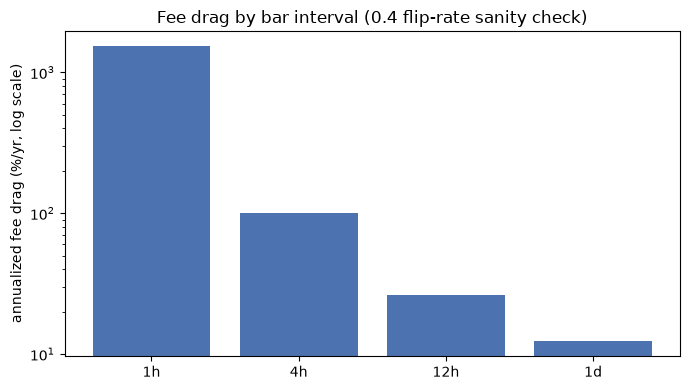

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(fee_drag_df["interval"], fee_drag_df["annual_fee_drag_pct"], color="#4C72B0")
ax.set_yscale("log")
ax.set_ylabel("annualized fee drag (%/yr, log scale)")
ax.set_title("Fee drag by bar interval (0.4 flip-rate sanity check)")
plt.tight_layout()
plt.show()

## Phase 1 - Universe (30 symbols, ragged panel)

30 USDT-M perpetual futures symbols chosen to include several 2021-era coins that
later died or were delisted (LUNA, MATIC, EOS) rather than picking today's
top-30-by-liquidity - avoids the obvious survivorship bias, though the list is still
hindsight-chosen (see results doc for the residual bias this doesn't fix).
`research.load_universe_panel` enforces the 2025-07-01 holdout freeze structurally
(raises unless `allow_holdout=True`), not by discipline.


In [5]:
SYMBOLS = [
    "BTCUSDT",
    "ETHUSDT",
    "BNBUSDT",
    "SOLUSDT",
    "XRPUSDT",
    "ADAUSDT",
    "DOGEUSDT",
    "DOTUSDT",
    "AVAXUSDT",
    "MATICUSDT",
    "LINKUSDT",
    "LTCUSDT",
    "ATOMUSDT",
    "UNIUSDT",
    "ETCUSDT",
    "XLMUSDT",
    "ALGOUSDT",
    "VETUSDT",
    "FILUSDT",
    "TRXUSDT",
    "EOSUSDT",
    "AAVEUSDT",
    "SANDUSDT",
    "MANAUSDT",
    "AXSUSDT",
    "THETAUSDT",
    "NEARUSDT",
    "FTMUSDT",
    "LUNAUSDT",
    "FTTUSDT",
]
START = datetime(2021, 7, 1, tzinfo=UTC)

coverage = []
for sym in SYMBOLS:
    df = data.download_klines_range(
        sym, "12h", START, research.HOLDOUT_START, cache_dir="cache", download_dir="tmp"
    )
    coverage.append(
        {
            "symbol": sym,
            "first_bar": df["datetime"].min(),
            "last_bar": df["datetime"].max(),
            "n_bars": len(df),
        }
    )

coverage_df = pl.DataFrame(coverage).sort("n_bars")
coverage_df.head(6)

symbol,first_bar,last_bar,n_bars
str,datetime[μs],datetime[μs],i64
"""LUNAUSDT""",2021-07-01 00:00:00,2022-05-13 00:00:00,623
"""MATICUSDT""",2021-07-01 00:00:00,2024-09-11 00:00:00,2337
"""FTTUSDT""",2022-04-15 00:00:00,2025-07-01 00:00:00,2347
"""EOSUSDT""",2021-07-01 00:00:00,2025-05-21 00:00:00,2841
"""SOLUSDT""",2021-07-01 00:00:00,2025-07-01 00:00:00,2913
"""XRPUSDT""",2021-07-01 00:00:00,2025-07-01 00:00:00,2913


LUNA (died in the Terra collapse), MATIC and EOS (delisted later) show up with
visibly shorter histories than the other 26 symbols - the ragged panel is real, not
hypothetical. `min_cross_section=10` drops any bar with too few symbols present
(e.g. the SOL/XRP Feb-Apr 2022 archive gap) before any cross-sectional ranking touches it.


## Phase 2 - Feature library

`src/features.py`: order flow (from `taker_buy_volume`/`count`, unused by notebooks
1-2), seasonality (cyclic hour/day-of-week), multi-window realized vol + vol-of-vol +
vol regime, momentum/mean-reversion, and a best-effort funding-rate feature (backward
asof join, causal). Every raw feature is verified causal by truncation testing in
`tests/test_features.py`. Quick demo of the causality guarantee:


In [6]:
panel_demo = research.load_universe_panel(
    SYMBOLS[:5],
    "12h",
    START,
    research.HOLDOUT_START,
    min_cross_section=3,
    cache_dir="cache",
    download_dir="tmp",
)
one_symbol = panel_demo.filter(pl.col("symbol") == "BTCUSDT").sort("datetime")

full = features.add_all_raw_features(one_symbol)
truncated = features.add_all_raw_features(one_symbol.head(200))

# every feature value for the first 200 rows must be identical whether or not
# the rows after row 200 exist - that's what "causal" means operationally.
mismatches = 0
for col in [c for c in full.columns if c not in one_symbol.columns]:
    a = full[col].head(200).to_numpy()
    b = truncated[col].to_numpy()
    if not np.allclose(a, b, equal_nan=True):
        mismatches += 1
print(
    f"{mismatches} feature columns changed when future rows were removed (should be 0)"
)

0 feature columns changed when future rows were removed (should be 0)


## Phase 3 - IC harness

`research.cross_sectional_ic` (per-timestamp Spearman IC across symbols, Newey-West
t-stat on the IC_t series) and `research.panel_ic` (stacked, Driscoll-Kraay-style
clustered+HAC SE). Demo against synthetic data with a known implanted IC:


In [7]:
rng = np.random.default_rng(1)
true_ic = 0.15
rows = []
for t in range(300):
    dt = datetime(2022, 1, 1, tzinfo=UTC) + timedelta(hours=12 * t)
    feat = rng.normal(size=30)
    noise = rng.normal(size=30)
    target = true_ic * feat + np.sqrt(1 - true_ic**2) * noise
    for s in range(30):
        rows.append(
            {"datetime": dt, "symbol": f"S{s}", "pred": feat[s], "target": target[s]}
        )

synthetic = pl.DataFrame(rows)
ic_df = research.cross_sectional_ic(synthetic, "pred", "target")
stats = research.cross_sectional_ic_stats(ic_df, nw_lag=5)
print(
    f"implanted IC=0.15, recovered mean_ic={stats['mean_ic']:.4f}, NW t-stat={stats['nw_tstat']:.2f}"
)

implanted IC=0.15, recovered mean_ic=0.1471, NW t-stat=14.67


## Phase 4 - IC screening

Screened all 27 raw candidate features across 4h/12h/1d against `fwd_return_1`
(`src/research/tmp/screen_features.py`) - 81 configs, all logged to `config_log.jsonl`.
Reloading that log rather than rerunning the screen (a few minutes of panel-wide
looped Spearman correlations, not worth repeating on every notebook execution).


In [8]:
with open("tmp/config_log.jsonl") as f:
    log_rows = [json.loads(line) for line in f]
screen_df = pl.DataFrame([r for r in log_rows if "feature" in r])
screen_df = screen_df.with_columns(pl.col("nw_tstat").abs().alias("abs_tstat")).sort(
    "abs_tstat", descending=True
)
screen_df.select(
    "feature",
    "interval",
    "mean_ic",
    "nw_tstat",
    "frac_positive_months",
    "sign_consistent_across_years",
).head(15)

feature,interval,mean_ic,nw_tstat,frac_positive_months,sign_consistent_across_years
str,str,f64,f64,f64,bool
"""hour_sin""","""4h""",NaN,NaN,NaN,false
"""hour_cos""","""4h""",NaN,NaN,NaN,false
"""dow_sin""","""4h""",NaN,NaN,NaN,false
"""dow_cos""","""4h""",NaN,NaN,NaN,false
"""hour_sin""","""12h""",NaN,NaN,NaN,false
…,…,…,…,…,…
"""dow_sin""","""1d""",NaN,NaN,NaN,false
"""dow_cos""","""1d""",NaN,NaN,NaN,false
"""log_return""","""4h""",-0.041667,-14.195982,0.0625,true


34 / 81 configs survive |t|>3 AND sign-consistent-across-years


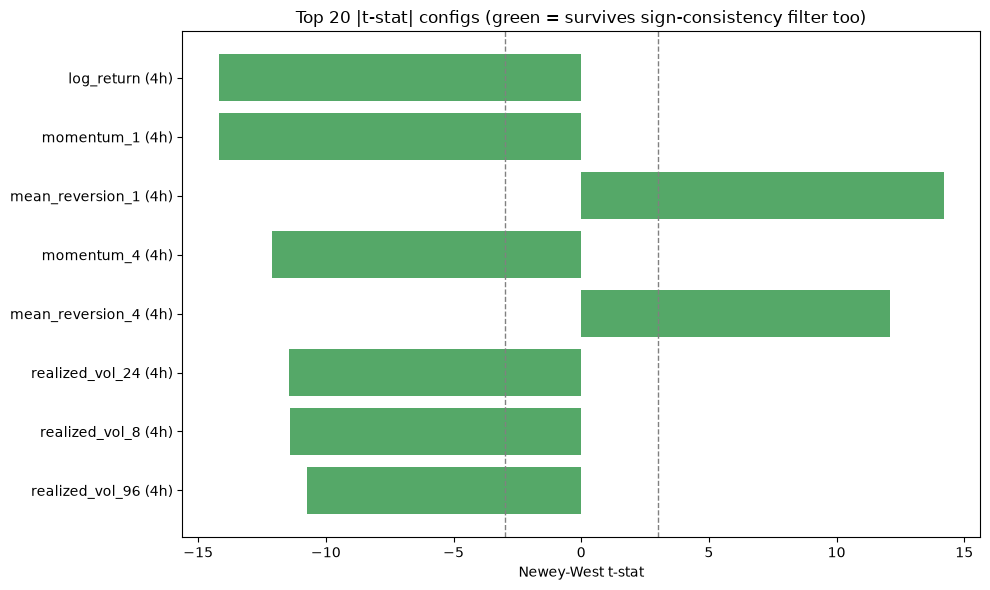

In [9]:
survivors = screen_df.filter(
    (pl.col("abs_tstat") > 3) & pl.col("sign_consistent_across_years")
)
print(
    f"{len(survivors)} / {len(screen_df)} configs survive |t|>3 AND sign-consistent-across-years"
)

fig, ax = plt.subplots(figsize=(10, 6))
top20 = screen_df.head(20).sort("abs_tstat")
colors = ["#55A868" if s else "#C44E52" for s in top20["sign_consistent_across_years"]]
ax.barh(
    [f"{f} ({i})" for f, i in zip(top20["feature"], top20["interval"])],
    top20["nw_tstat"],
    color=colors,
)
ax.axvline(3, color="gray", linestyle="--", linewidth=1)
ax.axvline(-3, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Newey-West t-stat")
ax.set_title("Top 20 |t-stat| configs (green = survives sign-consistency filter too)")
plt.tight_layout()
plt.show()

Mean-reversion (all three windows) and negative realized-vol are the strongest and
most stable survivors, at every interval. Seasonality features (`hour_sin/cos`,
`dow_sin/cos`) are structurally invisible to cross-sectional IC - day-of-week/hour is
identical for every symbol at a given bar, so they have exactly zero cross-sectional
variance by construction, at any interval. Nothing tripped the 0.10 lookahead
tripwire (max |mean IC| observed was 0.073).


## Phase 5 - Portfolio construction

`dollar_neutral_weights` (rank into long/short legs, size proportionally within each
leg via `vol_targeted_size`), `panel_walk_forward_splits` (folds over unique
timestamps so a pooled model's train/test boundary never splits one bar across
symbols), `portfolio_trade_frame`/`portfolio_metrics` (multi-symbol analogues of
Phase 0's cost/metrics helpers). Small demo:


In [10]:
demo_panel = (
    panel_demo.join(
        panel_demo.select("datetime", "symbol", "close").rename({"close": "_c"}),
        on=["datetime", "symbol"],
    )
    .with_columns(
        (pl.col("close") / pl.col("close").shift(1).over("symbol")).log().alias("pred")
    )
    .drop_nulls("pred")
)

weights = research.dollar_neutral_weights(
    demo_panel, "pred", top_frac=0.4, gross_exposure=1.0
)
weights.group_by("datetime").agg(
    pl.col("weight").sum().alias("net"), pl.col("weight").abs().sum().alias("gross")
).head(5)

datetime,net,gross
datetime[μs],f64,f64
2025-02-12 00:00:00,0.0,1.0
2023-04-10 12:00:00,0.0,1.0
2024-07-14 00:00:00,0.0,1.0
2022-12-21 00:00:00,0.0,1.0
2025-06-05 12:00:00,0.0,1.0


## Phase 6 - Backtest (3 pre-declared configs)

Pre-declared **before running** (see results doc): pooled linear model on
cross-sectionally standardized features (`mean_reversion_{1,4,12}`,
`realized_vol_{8,24,96}`, `vol_of_vol_96`, plus `funding_rate` for the 4h config -
the only ones that survived Phase 4 screening), vol-normalized target, vol-targeted
dollar-neutral sizing, 4h/12h/1d, each also re-run at origin offsets 0/7/14/21 days.

Rerunning the headline (offset=0) fold sequence for `cfg2_12h` live here (the
strongest config) to get a plottable equity curve; the full grid (all 3 configs x 4
offsets, ~1-2 CPU-minutes per config) already ran once via
`src/research/tmp/backtest_configs.py` and is reloaded from `config_log.jsonl` /
`backtest_results.json` below rather than repeated 12 times.


In [11]:
sys.path.insert(0, "tmp")
import backtest_configs as bc

funding_by_symbol = bc.load_funding_by_symbol()
cfg2 = {"id": "cfg2_12h", "interval": "12h", "features": list(bc.BASE_FEATURES)}

featured = bc.build_featured_panel("12h", funding_by_symbol)
featured = featured.with_columns(
    research.vol_normalized_target(target_col="fwd_return_1", vol_col="realized_vol_24")
)
feature_cols = [f"{c}_cs_z" for c in cfg2["features"]]
needed = [
    "datetime",
    "symbol",
    "fwd_return_1",
    "realized_vol_24",
    *feature_cols,
    "fwd_return_1_vol_norm",
]
df = featured.select(needed).drop_nulls().sort(["datetime", "symbol"])
df = df.filter(pl.col("realized_vol_24") > 1e-12)

vol_target = research._as_float(df["realized_vol_24"].median())
ar = research.sharpe_to_annualized_rate("12h")
splits = research.panel_walk_forward_splits(
    df, train_bars=730, test_bars=182, origin_offset=0
)

fold_frames = []
for fold_id, (train_idx, test_idx) in enumerate(splits):
    preds, _, desc = bc.train_predict_fold(
        df[train_idx], df[test_idx], feature_cols, "fwd_return_1_vol_norm"
    )
    test_scored = (
        df[test_idx]
        .with_columns(pl.Series("pred", preds))
        .with_columns(research.vol_targeted_size("pred", "realized_vol_24", vol_target))
    )
    w = research.dollar_neutral_weights(
        test_scored,
        "pred",
        size_col="vol_targeted_size",
        top_frac=0.2,
        max_position_per_symbol=0.25,
    )
    tf = research.portfolio_trade_frame(w, test_scored, target_col="fwd_return_1")
    fold_frames.append(tf.with_columns(pl.lit(fold_id).alias("fold")))

stitched = pl.concat(fold_frames, how="diagonal_relaxed").sort("datetime")
stitched = stitched.with_columns(
    pl.col("trade_log_return").cum_sum().alias("equity_curve")
)
costed = research.add_portfolio_costs(stitched, taker_fee=0.0004, slippage=0.0001)
basket = research.equal_weight_basket_returns(
    df.filter(pl.col("datetime").is_in(stitched["datetime"].implode()))
)
basket = basket.with_columns(pl.col("trade_log_return").cum_sum().alias("equity_curve"))

research.portfolio_metrics(stitched, ar, taker_fee=0.0004, slippage=0.0001)

{'label': 'portfolio',
 'no_bars': 2002,
 'total_log_return': 0.4111635668713053,
 'compound_return': 0.5085720887956007,
 'std': 0.01014271518010309,
 'sharpe': 0.5470887089557184,
 'max_drawdown': -0.5287694086265822,
 'sharpe_net': -0.6705161625697134,
 'total_log_return_net': -0.5036843241273501,
 'compound_return_net': -0.3956998842842292,
 'max_drawdown_net': -0.9373530927784745,
 'mean_turnover_per_bar': 0.9136846433248551,
 'turnover_per_year': np.float64(666.9897896271442),
 'annual_fee_drag_log': np.float64(0.33358589432018904),
 'annual_fee_drag_pct': 0.3959649468521861}

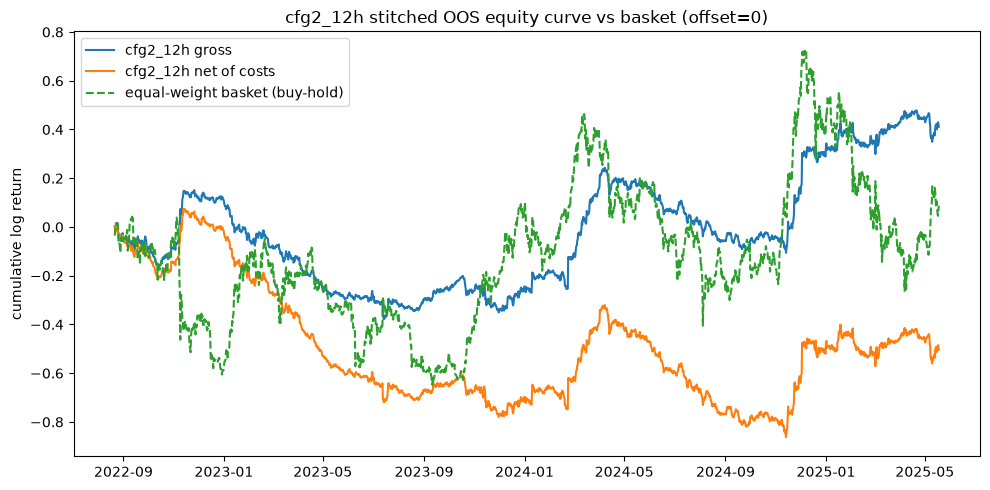

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(stitched["datetime"], stitched["equity_curve"], label="cfg2_12h gross")
ax.plot(costed["datetime"], costed["equity_curve_net"], label="cfg2_12h net of costs")
ax.plot(
    basket["datetime"],
    basket["equity_curve"],
    label="equal-weight basket (buy-hold)",
    linestyle="--",
)
ax.set_title("cfg2_12h stitched OOS equity curve vs basket (offset=0)")
ax.set_ylabel("cumulative log return")
ax.legend()
plt.tight_layout()
plt.show()

Gross beats the basket comfortably; net of costs it's much closer, and (per the
full origin-shift grid below) that headline result doesn't survive a one-week shift
in where the walk-forward grid starts.


In [13]:
# A couple of (config_id, origin_offset_days) pairs have >1 logged row - a debugging
# run before the zero-realized-vol fix also got appended, per "no exceptions, no
# undercounting" (see results doc). Take the last (final, post-fix) value per pair
# for this plot; every row, buggy or not, still counts toward the deflated Sharpe's
# true trial count.
backtest_log = pl.DataFrame(
    [r for r in log_rows if "config_id" in r and r.get("phase") != "holdout"]
)
backtest_log = backtest_log.group_by(
    "config_id", "origin_offset_days", maintain_order=True
).last()
pivot = backtest_log.pivot(
    on="origin_offset_days", index="config_id", values="sharpe_net"
)
pivot

config_id,0,7,14,21
str,f64,f64,f64,f64
"""cfg3_1d""",-0.291365,-1.151694,-1.662,-0.447065
"""cfg1_4h""",-1.942344,-4.199384,-3.910837,-3.103609
"""cfg2_12h""",0.417372,-2.451226,-1.123475,-0.958042


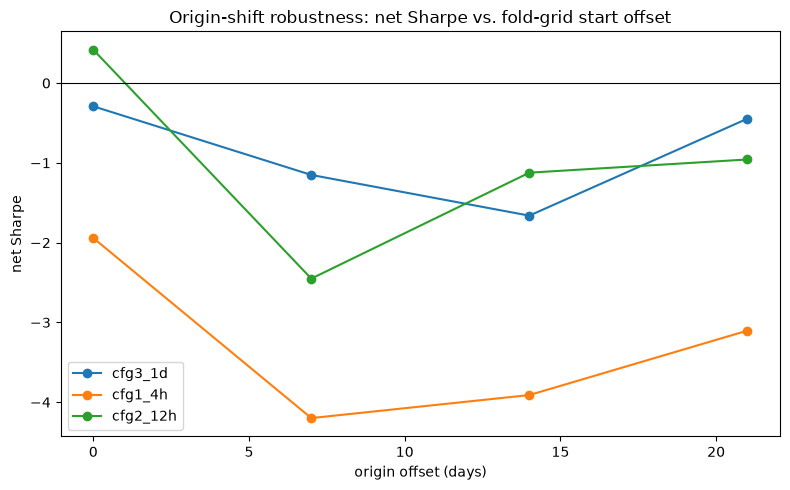

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
offsets = [0, 7, 14, 21]
for cfg_id in backtest_log["config_id"].unique(maintain_order=True):
    sub = backtest_log.filter(pl.col("config_id") == cfg_id).sort("origin_offset_days")
    ax.plot(sub["origin_offset_days"], sub["sharpe_net"], marker="o", label=cfg_id)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("origin offset (days)")
ax.set_ylabel("net Sharpe")
ax.set_title("Origin-shift robustness: net Sharpe vs. fold-grid start offset")
ax.legend()
plt.tight_layout()
plt.show()

Only `cfg2_12h` is ever positive, and only at offset=0 - every other point on every
line is negative. A result that depends on exactly where the walk-forward grid
happens to start isn't a result. Deflated Sharpe using the true 95-config count from
`config_log.jsonl`: `cfg2_12h`'s best trial gets P(true Sharpe > 0 | best of 95) =
3.4% (see results doc for the full calculation and the other two configs' numbers).


## Phase 7 - Holdout (spent once)

`cfg2_12h`, completely unchanged, run once on the frozen 2025-07-01 to 2026-07-01
window (`src/research/tmp/holdout_run.py`). Reloading the result rather than
rerunning - the holdout is spent once, and that includes not re-executing it
gratuitously in this notebook.


In [15]:
with open("tmp/holdout_results.json") as f:
    holdout = json.load(f)
print(
    f"holdout Sharpe net={holdout['holdout_metrics']['sharpe_net']:.3f}  "
    f"gross={holdout['holdout_metrics']['sharpe']:.3f}"
)
print(
    f"basket Sharpe={holdout['basket_metrics']['sharpe']:.3f}  "
    f"random baseline mean={holdout['random_metrics_summary']['mean_sharpe']:.3f}"
)
print(
    f"win rate vs basket={holdout['win_rate_vs_basket']:.2f}  "
    f"bootstrap 95% CI excess return={holdout['bootstrap_ci_excess_return']}"
)

pl.DataFrame(holdout["fold_summaries"]).select(
    "fold", "test_start", "test_end", "n_test_bars", "sharpe_net", "beats_basket"
)

holdout Sharpe net=-0.471  gross=0.744
basket Sharpe=-1.786  random baseline mean=-4.169
win rate vs basket=0.67  bootstrap 95% CI excess return=[-0.16917166683700235, 0.49514667156766534]


fold,test_start,test_end,n_test_bars,sharpe_net,beats_basket
i64,str,str,i64,f64,bool
12,"""2025-08-17T12:00:00.000000""","""2025-11-16T00:00:00.000000""",4550,0.779089,true
13,"""2025-11-16T12:00:00.000000""","""2026-02-15T00:00:00.000000""",4550,0.028508,true
14,"""2026-02-15T12:00:00.000000""","""2026-05-17T00:00:00.000000""",4550,-3.55824,false


Net Sharpe -0.47 (gross +0.74) on the one shot that matters most. Same pattern as
every other result in this run: gross-positive, cost-erased, bootstrap CI on excess
return includes zero.


## Bottom line

**No validated edge.** An IC-screened, statistically real (if modest) mean-reversion
/ realized-vol signal exists in the cross-sectional panel and is gross-profitable at
every interval and in the holdout year, but transaction costs consistently erase it.
The one config that looked good net of costs at its headline setting (`cfg2_12h`,
+0.42 Sharpe) didn't survive a one-week origin shift, its deflated Sharpe against the
true 95-config search count is 3.4%, its bootstrap CI on excess return includes zero,
and its one-shot holdout result came back Sharpe -0.47.

This matches `002_walk_forward_multi_asset.md`'s conclusion and extends it: neither the
fix for single-asset noise (30-symbol cross-sectional breadth) nor the fix for
gross-return blindness (real transaction costs everywhere) turned up a tradeable edge.
Full bug list, every number, and "what to test next" in `src/results/003_cross_sectional_ic.md`.
